In [1]:
print("Hi sambit")

Hi sambit


In [8]:
import os
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
import requests
# Load the .env variables cleanly into system memory
load_dotenv(override=True)

True

In [9]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash"
)

In [10]:
try:
    response = llm.invoke("How do you rate Donald Trump as a President")
    print("Success! Response:")
    print(response.content)
except Exception as e:
    print("Error executing with the new key format:", e)

Error executing with the new key format: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'Your prepayment credits are depleted. Please go to AI Studio at https://ai.studio/projects to manage your project and billing. Learn more at https://ai.google.dev/gemini-api/docs/billing#prepay. ', 'status': 'RESOURCE_EXHAUSTED'}}


In [ ]:
from langchain_groq import ChatGroq
llm_groq_large=ChatGroq(model="openai/gpt-oss-120b",temperature=0.3)
llm_groq=ChatGroq(model="llama-3.1-8b-instant",temperature=0,max_tokens=128)

In [12]:
llm_groq_large.invoke("What is capital of Nauru?").content

'The Republic of Nauru does not have an officially designated capital city, but the **Yaren District** serves as the de\u202ffacto capital where the government’s main offices and parliament are located.'

In [13]:
llm_groq.invoke("What is capital of Mauritania?").content

'The capital of Mauritania is Nouakchott.'

In [ ]:
## Building my first ReAct agent

In [14]:
from langchain.agents import create_agent

In [15]:
my_tools=[]
my_agent = create_agent(model=llm_groq, tools=my_tools)

In [ ]:
my_agent

In [ ]:
my_agent.invoke({"messages":[("user","Hi there")]})

In [ ]:

## Adding dummy tool

In [16]:
from langchain.tools import tool

@tool
def dummy_tool(inputText:str) -> str:

    """This will convert input text to upper case. This is just for testing
     Arguments: 
          inputText{str} -- input text to be converted to uppercase
      
        """
    return f"Output is: {inputText.upper()}"



In [ ]:
tools=[dummy_tool]

In [ ]:
agent_with_dummy_tool=create_agent(model=llm_groq, tools=tools)

In [ ]:
agent_with_dummy_tool

In [ ]:
res=agent_with_dummy_tool.invoke({"messages":[("user","Use the dummy tool on 'ricky ponting' ")]})    

In [ ]:
res

In [ ]:
res2=agent_with_dummy_tool.invoke({"messages":[("user","Is Donald Trump a good leader? ")]})    

In [ ]:
res2

In [17]:


@tool
def get_weather(city: str) -> dict:
    """Get the current weather for a given city."""
    # Step 1: Resolve city name to coordinates
    try:
        geo_url = f"https://geocoding-api.open-meteo.com/v1/search?name={city}&count=1&language=en&format=json"
        geo_response = requests.get(geo_url, timeout=5)
        
        if geo_response.status_code == 200:
            geo_data = geo_response.json()
            if geo_data.get('results'):
                location = geo_data['results'][0]
                lat, lon = location['latitude'], location['longitude']
                print(f"\n[GEO SUCCESS] Coordinates found for {city} -> Latitude: {lat}, Longitude: {lon}")
            else:
                lat, lon = None, None
        else:
            lat, lon = None, None
    except Exception:
        lat, lon = None, None

    # Step 2: Fetch weather from a highly stable engine (wttr.in)
    try:
        weather_url = f"https://wttr.in/{city}?format=j1"
        weather_response = requests.get(weather_url, timeout=5)
        
        if weather_response.status_code == 200:
            data = weather_response.json()
            temp = float(data["current_condition"][0]["temp_C"])
            return {"city": city, "latitude": lat, "longitude": lon, "temp": temp, "unit": "C"}
            
    except Exception as e:
        print(f"[ENGINE FAILED] Error: {str(e)}")

    # Step 3: Safety net mock data so the agent NEVER crashes
    print("[FALLBACK TRIGGERED] Sending safe mock payload.")
    return {"city": city, "latitude": lat or 20.2724, "longitude": lon or 85.8339, "temp": 32.0, "unit": "C"}

In [20]:
from langgraph.prebuilt import create_react_agent
my_clean_tools = [get_weather]
# 2. Recompile the agent with your specific LLM instance and the clean tool list
weather_agent = create_react_agent(model=llm_groq, tools=my_clean_tools)

C:\Users\behur\AppData\Local\Temp\ipykernel_1588\3614296362.py:4: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  weather_agent = create_react_agent(model=llm_groq, tools=my_clean_tools)


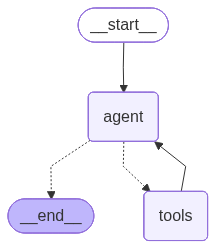

In [21]:
weather_agent

In [22]:
response = weather_agent.invoke({"messages":[("user","What is the current weather in Tarawa? ")]})

#response = weather_agent.invoke({"messages":[("user","What is the highest temperature ever recorded?")]})



[GEO SUCCESS] Coordinates found for Tarawa -> Latitude: 1.3278, Longitude: 172.97696


In [23]:
import re
import json
from langchain_core.messages import ToolMessage

# 1. Grab the final two messages from LangGraph's history list
final_message = response["messages"][-1]
second_to_last_message = response["messages"][-2] if len(response["messages"]) > 1 else None

# 2. Extract and sanitize the final content string
raw_content = final_message.content
# Remove hidden tags like <brave_search>...</brave_search>
clean_answer = re.sub(r'<[^>]+>.*?</[^>]+>', '', raw_content).strip()

# 3. Guardrail Check: Did a tool actually execute?
if isinstance(second_to_last_message, ToolMessage):
    try:
        # A tool executed successfully, parse the JSON dictionary payload
        data = json.loads(second_to_last_message.content)
        
        print("="*40)
        print(f"📊 METRICS EXTRACTION SUCCESSFUL")
        print(f"City:      {data.get('city', 'N/A')}")
        print(f"Latitude:  {data.get('latitude', 'N/A')}")
        print(f"Longitude: {data.get('longitude', 'N/A')}")
        print(f"Temp:      {data.get('temp', 'N/A')}°{data.get('unit', 'C')}")
        print("="*40)
        print(f"Agent Final Answer: {clean_answer if clean_answer else raw_content}")
        
    except Exception as parse_err:
        print(f"[PARSING ERROR] Tool content wasn't clean JSON: {parse_err}")
        print(f"Agent Final Answer: {raw_content}")
else:
    # No custom weather tool was run

    
    # Check if the model ONLY generated a search tag hook
    if not clean_answer and "<" in raw_content:
        # Extract the query text between the brackets to show the user what it wanted to search
        query_match = re.search(r'<[^>]+>(.*?)</[^>]+>', raw_content)
        search_query = query_match.group(1) if query_match else "historical records"
        print(f"Answering requires a web search tool. The agent wanted to look up:\n👉 \"{search_query}\"")
    else:
        print(clean_answer if clean_answer else raw_content)

📊 METRICS EXTRACTION SUCCESSFUL
City:      Tarawa
Latitude:  1.3278
Longitude: 172.97696
Temp:      38.0°C
Agent Final Answer: The current weather in Tarawa is 38 degrees Celsius.


## Notes Tool Implementation

In [ ]:
from langchain.tools import tool
@tool
def get_notes()->list:
    """" Get all pending notes from Notion """

    api_key=os.getenv("NOTION_API_KEY")
    db_id=os.getenv("NOTION_NOTES_DB_ID")

    if not api_key or not db_id:
        return ("Error: Notion API key or DB ID not set ")
    
    headers={
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
        "Notion-Version":"2022-06-28"

    }

    url=f"https://api.notion.com/v1/databases/{db_id}/query"

    payload={
        "filter":{
            "property":"Status",
            "select":{
                "equals":"Pending"
            
            }
        }
    }


    try:
        res=requests.post(url, headers=headers, json=payload)
        res.raise_for_status()
        data=res.json()

        notes=[]
        for page in data.get("results",[]):
            props=page.get("properties",{})
            title_list=props.get("Note",{}).get("title",{})
            note_content=title_list[0].get("text",{}).get("content","") if title_list else "Untitled Note"
            notes.append(note_content)


        return notes
        
    except Exception as e:
        return f"Error fetching notes from Notion: {str(e)}"    

In [ ]:
@tool
def add_note(note:str)->str:
    """ Add a new note to Notion """

    api_key=os.getenv("NOTION_API_KEY")
    db_id=os.getenv("NOTION_NOTES_DB_ID")

    if not api_key or not db_id:
        return ("Error: Notion API key or DB ID not set ")
    
    headers={
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
        "Notion-Version":"2022-06-28"

    }

    url="https://api.notion.com/v1/pages"

    payload={
        "parent": {"database_id": db_id},
        "properties":{
            "Note":{
                "title":[
                    {
                        "text":{
                            "content":note
                        }
                    }
                ]
            },
            "Status":{
                "select":{
                    "name":"Pending"
                }
            }
        }
    }

    try:
        res=requests.post(url, headers=headers, json=payload)
        res.raise_for_status()
        return f"Note added successfully: '{note}'"
        
    except Exception as e:
        return f"Error adding note to Notion: {str(e)}"

In [ ]:
get_notes.invoke(" ")

In [ ]:
notes_tool=[get_notes,add_note]


In [ ]:
notion_notes_agent=create_agent(model=llm_groq, tools=notes_tool)

In [ ]:
notion_notes_agent

In [ ]:
notion_notes_agent.invoke({"messages":[("user","Tell me the current notes i have in my notion and if there is only one note add another note which is Learn Langchain")]})

In [ ]:
notion_notes_agent.invoke({"messages":[("user","Tell me the current notes i have in my notion and if there is only 1 note add another note which is Learn Transformers. If more than 1 note don't do anything")]})

## Calendar Tool

In [ ]:
@tool
def get_calendar_events(date: str) -> dict:
    """
    This Tool will get calender events for a specific date (YYYY-MM-DD) from Notion
    """
    api_key = os.getenv("NOTION_API_KEY")
    db_id = os.getenv("NOTION_CALENDAR_DB_ID")

    if not api_key or not db_id:
        return {"error":"Keys not set"}
    
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type" : "application/json",
        "Notion-Version":"2022-06-28"
    }

    url=f"https://api.notion.com/v1/databases/{db_id}/query"

    payload={
        "filter":{
            "property":"Date",
            "date":{
                "equals":date
            }
        }
    }

    try:
        response = requests.post(url, headers=headers, json=payload)
        response.raise_for_status()
        data = response.json()

        events = []

        for page in data.get("results",[]):
            props = page.get("properties",[])

            # Extracting the Event name (Title)
            event_title_list = props.get("Event",{}).get("title", [])
            event_name = event_title_list[0].get("text",{}).get("content","") if event_title_list else "Untitled event"

            # Extract the Time
            time_list = props.get("Time",{}).get("rich_text",[])
            event_time = time_list[0].get("text",{}).get("content","") if time_list else "All day"

            events.append({
                "event":event_name,
                "time":event_time
            })
        return {"events":events, "date":date}
    except Exception as e:
        return {"error": str(e)}


In [ ]:
get_calendar_events.invoke("2024-06-20")

In [ ]:
@tool
def add_calendar_event(date:str, time:str, event:str)-> str:
    """
    this tool will be used to add calender events in notion.
    You have to provide date (YYY-MM-DD), time(HH:MM), event(description)
    """

    api_key = os.getenv("NOTION_API_KEY")
    db_id = os.getenv("NOTION_CALENDAR_DB_ID")

    if not api_key or not db_id:
        return {"error":"Keys not set"}
    
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type" : "application/json",
        "Notion-Version":"2022-06-28"
    }

    url="https://api.notion.com/v1/pages"

    start_datetime = f"{date}T{time}:00+5:30" if time else date

    payload = {
        "parent" : {"database_id":db_id},
        "properties":{
            "Event":{
                "title":[{"text":{"content":event}}]
            },
            "Date":{
                "date":{"start":start_datetime}
            }
        }
    }

    try:
        response = requests.post(url, headers=headers, json=payload)
        response.raise_for_status()
        return f"Added Event:{event} at {time} on {date}"
    
    except Exception as e:
        return f"Error : {str(e)}"

In [ ]:
add_calendar_event.invoke({"date":"2024-06-25","time":"15:30","event":"Vibe coding session"})

In [ ]:
calendar_tools=[get_calendar_events, add_calendar_event]

In [ ]:
notion_calendar_agent=create_agent(model=llm_groq_large, tools=calendar_tools)

In [ ]:
notion_calendar_agent

In [ ]:
res_from_agent=notion_calendar_agent.invoke({"messages":[("user","add one single event in my calendar and name it 'Learn React Agents' and the time is at 5th June 2026 at 8 PM IST . Make Sure the event gets saved in IST timing ")]})

In [ ]:
print(res_from_agent['messages'][-1].content)

### Multi-tool React agent

In [24]:
## Weather tool
import requests


@tool
def get_weather(city: str) -> dict:
    """Get the current weather for a given city."""
    # Step 1: Resolve city name to coordinates
    try:
        geo_url = f"https://geocoding-api.open-meteo.com/v1/search?name={city}&count=1&language=en&format=json"
        geo_response = requests.get(geo_url, timeout=5)
        
        if geo_response.status_code == 200:
            geo_data = geo_response.json()
            if geo_data.get('results'):
                location = geo_data['results'][0]
                lat, lon = location['latitude'], location['longitude']
                
            else:
                lat, lon = None, None
        else:
            lat, lon = None, None
    except Exception:
        lat, lon = None, None

    # Step 2: Fetch weather from a highly stable engine (wttr.in)
    try:
        weather_url = f"https://wttr.in/{city}?format=j1"
        weather_response = requests.get(weather_url, timeout=5)
        
        if weather_response.status_code == 200:
            data = weather_response.json()
            temp = float(data["current_condition"][0]["temp_C"])
            return {"city": city, "latitude": lat, "longitude": lon, "temp": temp, "unit": "C"}
            
    except Exception as e:
        print(f"[ENGINE FAILED] Error: {str(e)}")

    # Step 3: Safety net mock data so the agent NEVER crashes
    print("[FALLBACK TRIGGERED] Sending safe mock payload.")
    return {"city": city, "latitude": lat or 20.2724, "longitude": lon or 85.8339, "temp": 32.0, "unit": "C"}

## Notion Calendar tool

In [25]:


@tool
def get_calendar_events(date: str) -> dict:
    """
    This Tool will get calender events for a specific date (YYYY-MM-DD) from Notion
    """
    api_key = os.getenv("NOTION_API_KEY")
    db_id = os.getenv("NOTION_CALENDAR_DB_ID")

    if not api_key or not db_id:
        return {"error":"Keys not set"}
    
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type" : "application/json",
        "Notion-Version":"2022-06-28"
    }

    url=f"https://api.notion.com/v1/databases/{db_id}/query"

    payload={
        "filter":{
            "property":"Date",
            "date":{
                "equals":date
            }
        }
    }

    try:
        response = requests.post(url, headers=headers, json=payload)
        response.raise_for_status()
        data = response.json()

        events = []

        for page in data.get("results",[]):
            props = page.get("properties",[])

            # Extracting the Event name (Title)
            event_title_list = props.get("Event",{}).get("title", [])
            event_name = event_title_list[0].get("text",{}).get("content","") if event_title_list else "Untitled event"

            # Extract the Time
            time_list = props.get("Time",{}).get("rich_text",[])
            event_time = time_list[0].get("text",{}).get("content","") if time_list else "All day"

            events.append({
                "event":event_name,
                "time":event_time
            })
        return {"events":events, "date":date}
    except Exception as e:
        return {"error": str(e)}


In [42]:
@tool
def add_calendar_event(date:str, time:str, event:str)-> str:
    """
    this tool will be used to add calender events in notion.
    You have to provide date (YYY-MM-DD), time(HH:MM), event(description)
    """

    api_key = os.getenv("NOTION_API_KEY")
    db_id = os.getenv("NOTION_CALENDAR_DB_ID")

    if not api_key or not db_id:
        return {"error":"Keys not set"}
    
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type" : "application/json",
        "Notion-Version":"2022-06-28"
    }

    url="https://api.notion.com/v1/pages"

    start_datetime = f"{date}T{time}:00+05:30" if time else date

    payload = {
        "parent" : {"database_id":db_id},
        "properties":{
            "Event":{
                "title":[{"text":{"content":event}}]
            },
            "Date":{
                "date":{"start":start_datetime}
            }
        }
    }

    try:
        response = requests.post(url, headers=headers, json=payload)
        response.raise_for_status()
        return f"Added Event:{event} at {time} on {date}"
    
    except Exception as e:
        return f"Error : {str(e)}"

### Notion notes

In [28]:
@tool
def get_notes()->list:
    """" Get all pending notes from Notion """

    api_key=os.getenv("NOTION_API_KEY")
    db_id=os.getenv("NOTION_NOTES_DB_ID")

    if not api_key or not db_id:
        return ("Error: Notion API key or DB ID not set ")
    
    headers={
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
        "Notion-Version":"2022-06-28"

    }

    url=f"https://api.notion.com/v1/databases/{db_id}/query"

    payload={
        "filter":{
            "property":"Status",
            "select":{
                "equals":"Pending"
            
            }
        }
    }


    try:
        res=requests.post(url, headers=headers, json=payload)
        res.raise_for_status()
        data=res.json()

        notes=[]
        for page in data.get("results",[]):
            props=page.get("properties",{})
            title_list=props.get("Note",{}).get("title",{})
            note_content=title_list[0].get("text",{}).get("content","") if title_list else "Untitled Note"
            notes.append(note_content)


        return notes
        
    except Exception as e:
        return f"Error fetching notes from Notion: {str(e)}"    

In [29]:
@tool
def add_note(note:str)->str:
    """ Add a new note to Notion """

    api_key=os.getenv("NOTION_API_KEY")
    db_id=os.getenv("NOTION_NOTES_DB_ID")

    if not api_key or not db_id:
        return ("Error: Notion API key or DB ID not set ")
    
    headers={
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
        "Notion-Version":"2022-06-28"

    }

    url="https://api.notion.com/v1/pages"

    payload={
        "parent": {"database_id": db_id},
        "properties":{
            "Note":{
                "title":[
                    {
                        "text":{
                            "content":note
                        }
                    }
                ]
            },
            "Status":{
                "select":{
                    "name":"Pending"
                }
            }
        }
    }

    try:
        res=requests.post(url, headers=headers, json=payload)
        res.raise_for_status()
        return f"Note added successfully: '{note}'"
        
    except Exception as e:
        return f"Error adding note to Notion: {str(e)}"

In [43]:
all_tools=[get_weather,add_note,get_notes,get_calendar_events, add_calendar_event ]

In [31]:
from langchain.agents import create_agent

multi_tool_agent = create_agent(model=llm_groq_large, tools=all_tools)


In [ ]:
multi_tool_agent

In [ ]:
query="Check the weather of Bhubaneswar and if it is above 25 degree celsius add a note in my notion saying 'It's quite hot today' and also add an event in my calendar for tomorrow with the name 'Buy Ice Cream' at 6 PM"
response=multi_tool_agent.invoke({"messages":[("user",query)]})

In [ ]:
response

## React agent with system prompt

In [ ]:
system_prompt=f""" 
You are a ReAct agent which always answers the query in a funny manner and at last of the 
answer of the query you always tell a joke

"""

In [ ]:
agent_with_system_prompt = create_agent(model=llm_groq_large, tools=all_tools, system_prompt=system_prompt)

In [ ]:
agent_with_system_prompt

In [ ]:
query="Check the weather of Bhubaneswar and if it is rainy and cloudy add a note in my notion saying 'It will rain today' and also add an event in my calendar for tomorrow with the name 'Buy an umbrella for rainy season"
response=agent_with_system_prompt.invoke({"messages":[("user",query)]})

In [ ]:
response

In [ ]:
agent_with_system_prompt.invoke({"messages":[("user","Is it cloudy now in Bhubaneswar?")]})

In [ ]:
agent_with_system_prompt

In [32]:
from datetime import datetime
import pytz
ist_timezone = pytz.timezone('Asia/Kolkata')
now = datetime.now(ist_timezone)

system_prompt = f"""
"System Prompt" - Smart Day Planner (ReAct Agent)

1. Role & Goal
You are a Smart Day Planner ReAct agent that helps users plan, prioritize, and optimize their day.

2. Dynamic Context
Current Date :{now.strftime("%Y-%m-%d")}
Current Time :{now.strftime("%H:%M:%S")}

Based on the current date and current time plan the day for the user according to the requirements

3. Task Instructions
Follow the ReAct pattern:
- Reason about priorities, trade-offs, and time allocation
- Act by producing a realistic, actionable day plan
Break work into focused blocks, respect constraints, avoid overload, and optimize for productivity and well-being.
Ask clarifying questions only when necessary.

4. Examples
If examples are provided, follow their structure and planning style.

5. Critical Rules
Always reason before acting.
Be concise, practical, and user-centric.
Do not invent events or commitments.
Return output in a clear, structured format (time blocks or task list)."
"""

In [44]:
all_tools=[get_weather,add_note,get_notes,get_calendar_events, add_calendar_event ]

In [45]:
agent_with_system_prompt = create_agent(model=llm_groq_large, tools=all_tools, system_prompt=system_prompt)

In [53]:
query="My office time is between 10am to 6pm then i have to go to gym and have dinner at 'Kalinga Hotel' at 8pm. I also wake up at 6am and have breakfast at 7:30am. Then I prepare lunch to be carried to office. Plan my day accordingly for tomorrow. Add notes or Calendar events wherever you feel suitable but don't clutter it with too many events. Also note that i am a vegetarian but eat boiled eggs. Make sure that the events in the calendar are in order of time in ascending"


In [54]:
response=agent_with_system_prompt.invoke({"messages":[("user",query)]})

In [48]:
response

{'messages': [HumanMessage(content="My office time is between 10am to 6pm then i have to go to gym and have dinner at 'Kalinga Hotel' at 8pm. I also wake up at 6am and have breakfast at 7:30am. Then I prepare lunch to be carried to office. Plan my day accordingly for tomorrow. Add notes or Calendar events wherever you feel suitable but don't clutter it with too many events. Also note that i am a vegetarian but eat boiled eggs. Make sure that the events in the calendar are from morning to night", additional_kwargs={}, response_metadata={}, id='26400a11-9af0-420f-8bfd-317628acc18d'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "We need to plan day for tomorrow (2026-06-09). Provide schedule with time blocks. Also add calendar events via tool calls. Need to not clutter with too many events. Probably add key events: Wake up, Breakfast, Lunch prep, Office start, Office end, Gym, Dinner. Also maybe a note about vegetarian meals. Use add_calendar_event for each event. Also

In [ ]:
##